========= Kalman Filter (KF) =========
RMSE -> X: 1.4865, Y: 1.5010
MAE  -> X: 1.0693, Y: 1.1130

========= Extended Kalman Filter (EKF) =========
RMSE -> X: 1.4865, Y: 1.5010
MAE  -> X: 1.0693, Y: 1.1130

========= Unscented Kalman Filter (UKF) =========
RMSE -> X: 1.4865, Y: 1.5010
MAE  -> X: 1.0693, Y: 1.1130


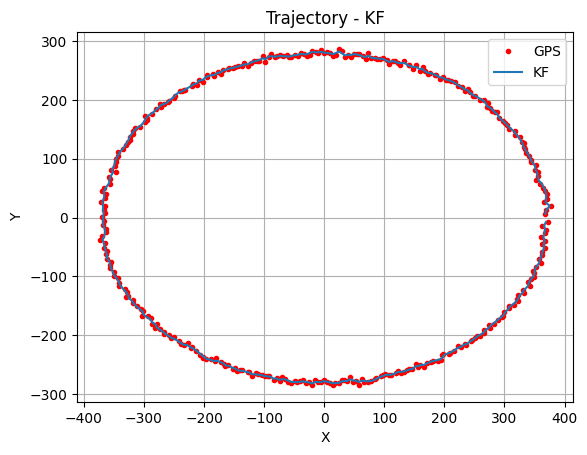

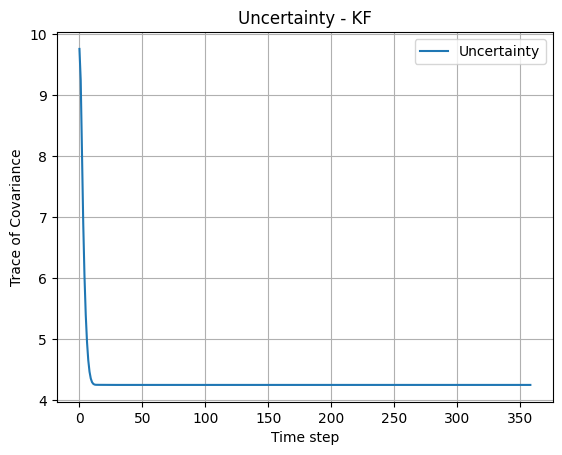

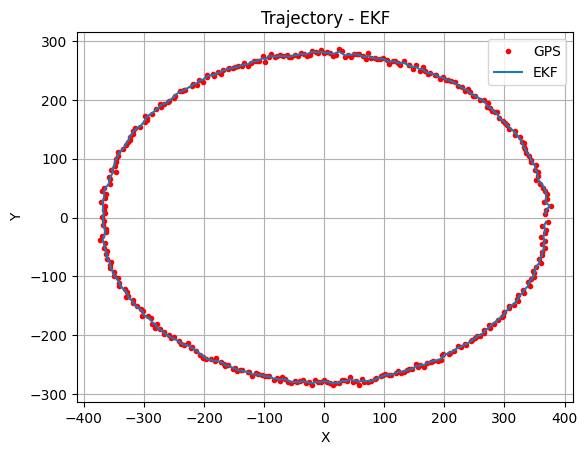

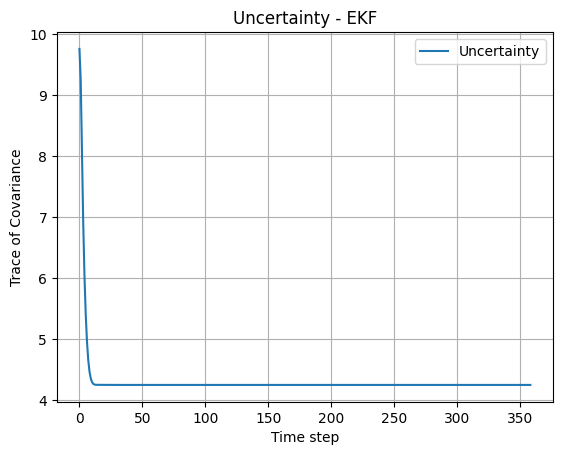

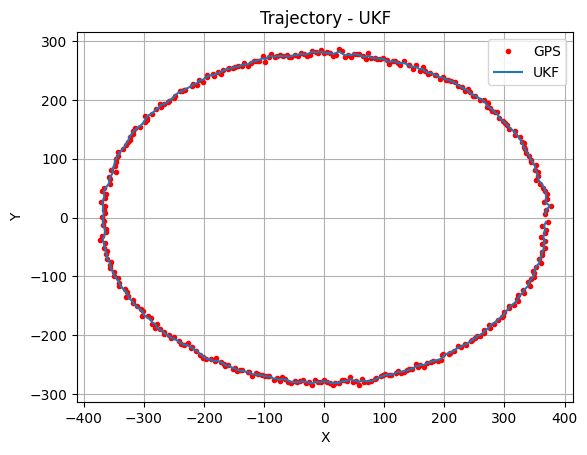

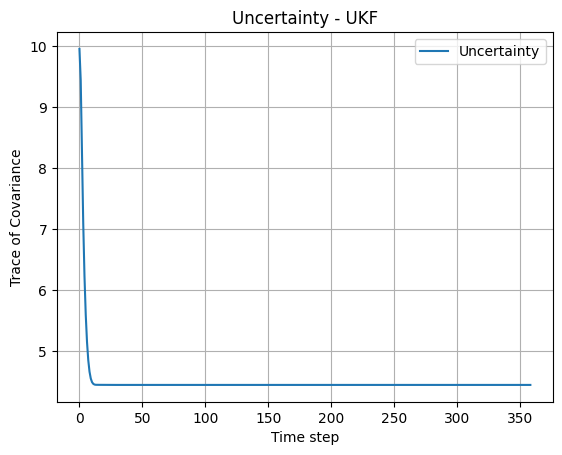

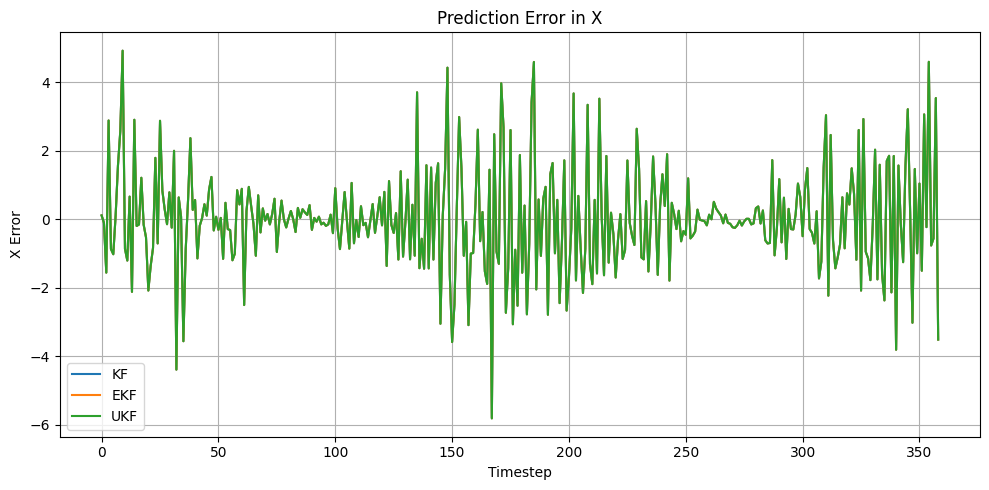

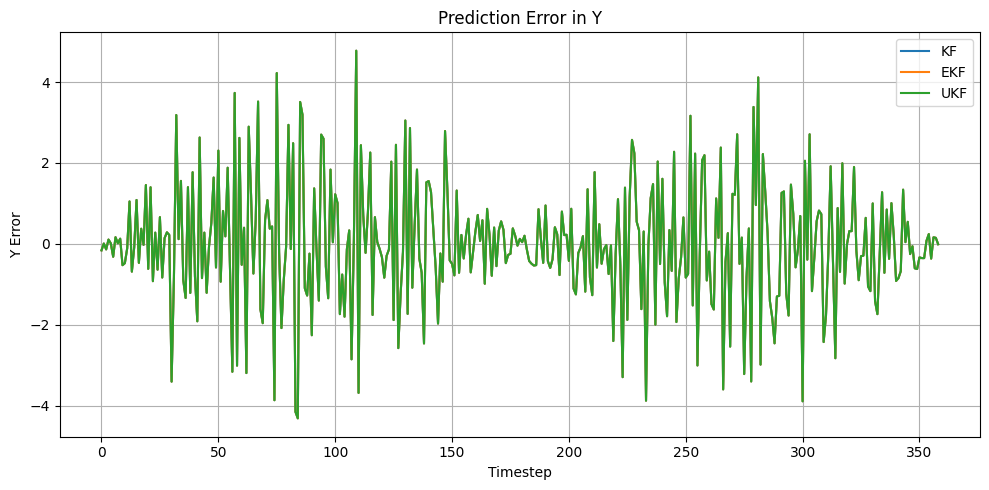

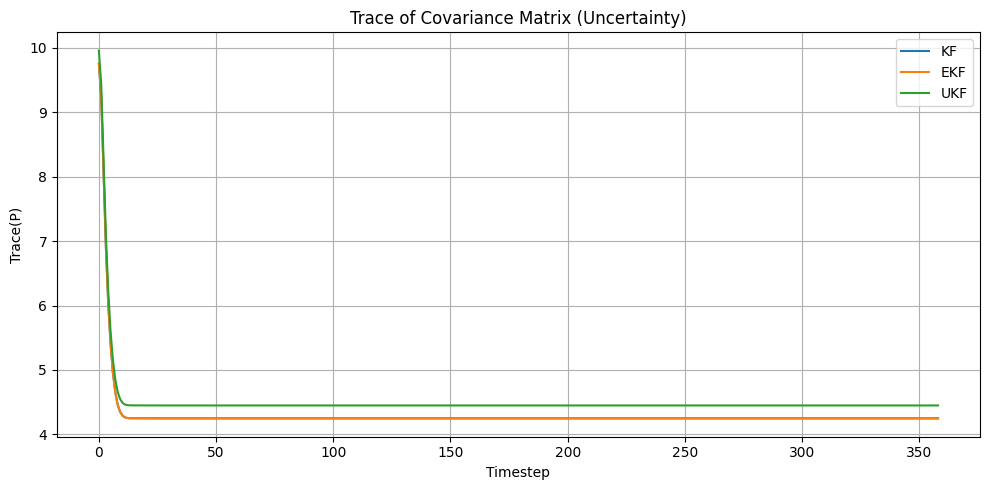

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter, ExtendedKalmanFilter, UnscentedKalmanFilter as UKF
from filterpy.kalman import MerweScaledSigmaPoints

# Load data
def load_data(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    initial = np.fromstring(lines[0], sep=',')
    data = np.array([np.fromstring(line.strip(), sep=',') for line in lines[1:]])
    return initial, data

# Basic linear Kalman Filter
def run_kf(initial, data):
    kf = KalmanFilter(dim_x=4, dim_z=2)
    dt = 1
    kf.F = np.array([[1, 0, dt, 0],
                     [0, 1, 0, dt],
                     [0, 0, 1, 0],
                     [0, 0, 0, 1]])
    kf.H = np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0]])
    kf.x = np.array([initial[0], initial[1], 0, 0])
    kf.P *= 100
    kf.R = np.eye(2) * 5
    kf.Q = np.eye(4) * 0.1

    predictions = []
    for z in data:
        gps_x, gps_y, vel_x, vel_y = z
        kf.predict()
        kf.update([gps_x, gps_y])
        predictions.append((kf.x[:2].copy(), kf.P[:2, :2].copy()))
        kf.x[2] = vel_x
        kf.x[3] = vel_y
    return predictions

# Extended Kalman Filter
def hx(x):
    return np.array([x[0], x[1]])

def H_jacobian(x):
    return np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0]])

def run_ekf(initial, data):
    ekf = ExtendedKalmanFilter(dim_x=4, dim_z=2)
    dt = 1
    ekf.F = np.array([[1, 0, dt, 0],
                      [0, 1, 0, dt],
                      [0, 0, 1, 0],
                      [0, 0, 0, 1]])
    ekf.x = np.array([initial[0], initial[1], 0, 0])
    ekf.P *= 100
    ekf.R = np.eye(2) * 5
    ekf.Q = np.eye(4) * 0.1

    predictions = []
    for z in data:
        gps_x, gps_y, vel_x, vel_y = z
        ekf.predict()
        ekf.update([gps_x, gps_y], H_jacobian, hx)
        predictions.append((ekf.x[:2].copy(), ekf.P[:2, :2].copy()))
        ekf.x[2] = vel_x
        ekf.x[3] = vel_y
    return predictions

# Unscented Kalman Filter
def fx(x, dt):
    F = np.array([[1, 0, dt, 0],
                  [0, 1, 0, dt],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]])
    return np.dot(F, x)

def run_ukf(initial, data):
    dt = 1
    points = MerweScaledSigmaPoints(n=4, alpha=0.1, beta=2., kappa=1)
    ukf = UKF(dim_x=4, dim_z=2, fx=fx, hx=hx, dt=dt, points=points)

    ukf.x = np.array([initial[0], initial[1], 0, 0])
    ukf.P *= 100
    ukf.R = np.eye(2) * 5
    ukf.Q = np.eye(4) * 0.1

    predictions = []
    for z in data:
        gps_x, gps_y, vel_x, vel_y = z
        ukf.predict()
        ukf.update([gps_x, gps_y])
        predictions.append((ukf.x[:2].copy(), ukf.P[:2, :2].copy()))
        ukf.x[2] = vel_x
        ukf.x[3] = vel_y
    return predictions

# Visualization
def visualize(data, predictions, label):
    measured = data[:, :2]
    pred = np.array([p[0] for p in predictions])
    uncertainties = np.array([np.trace(p[1]) for p in predictions])

    plt.figure()
    plt.plot(measured[:, 0], measured[:, 1], 'r.', label='GPS')
    plt.plot(pred[:, 0], pred[:, 1], '-', label=label)
    plt.title(f"Trajectory - {label}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid()

    plt.figure()
    plt.plot(uncertainties, label='Uncertainty')
    plt.title(f"Uncertainty - {label}")
    plt.xlabel("Time step")
    plt.ylabel("Trace of Covariance")
    plt.legend()
    plt.grid()
    plt.show()

# Error analysis
def compute_errors(predictions, data):
    pred_pos = np.array([p[0] for p in predictions])
    gps_pos = data[:, :2]
    errors = pred_pos - gps_pos
    mse = np.mean(errors**2, axis=0)
    mae = np.mean(np.abs(errors), axis=0)
    rmse = np.sqrt(mse)
    uncertainty_trace = [np.trace(p[1]) for p in predictions]
    return rmse, mae, errors, uncertainty_trace

def plot_errors(errors_dict):
    # Plot X error
    plt.figure(figsize=(10, 5))
    for method, (_, _, errors, _) in errors_dict.items():
        plt.plot([e[0] for e in errors], label=method)
    plt.title("Prediction Error in X")
    plt.xlabel("Timestep")
    plt.ylabel("X Error")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Plot Y error
    plt.figure(figsize=(10, 5))
    for method, (_, _, errors, _) in errors_dict.items():
        plt.plot([e[1] for e in errors], label=method)
    plt.title("Prediction Error in Y")
    plt.xlabel("Timestep")
    plt.ylabel("Y Error")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Plot uncertainty (trace of P)
    plt.figure(figsize=(10, 5))
    for method, (_, _, _, trace) in errors_dict.items():
        plt.plot(trace, label=method)
    plt.title("Trace of Covariance Matrix (Uncertainty)")
    plt.xlabel("Timestep")
    plt.ylabel("Trace(P)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    initial, data = load_data("input.txt")

    # Run each filter and compute errors
    preds_kf = run_kf(initial, data)
    rmse_kf, mae_kf, errors_kf, trace_kf = compute_errors(preds_kf, data)

    preds_ekf = run_ekf(initial, data)
    rmse_ekf, mae_ekf, errors_ekf, trace_ekf = compute_errors(preds_ekf, data)

    preds_ukf = run_ukf(initial, data)
    rmse_ukf, mae_ukf, errors_ukf, trace_ukf = compute_errors(preds_ukf, data)

    # Print separately
    print("========= Kalman Filter (KF) =========")
    print(f"RMSE -> X: {rmse_kf[0]:.4f}, Y: {rmse_kf[1]:.4f}")
    print(f"MAE  -> X: {mae_kf[0]:.4f}, Y: {mae_kf[1]:.4f}")

    print("\n========= Extended Kalman Filter (EKF) =========")
    print(f"RMSE -> X: {rmse_ekf[0]:.4f}, Y: {rmse_ekf[1]:.4f}")
    print(f"MAE  -> X: {mae_ekf[0]:.4f}, Y: {mae_ekf[1]:.4f}")

    print("\n========= Unscented Kalman Filter (UKF) =========")
    print(f"RMSE -> X: {rmse_ukf[0]:.4f}, Y: {rmse_ukf[1]:.4f}")
    print(f"MAE  -> X: {mae_ukf[0]:.4f}, Y: {mae_ukf[1]:.4f}")

    # Visualize
    visualize(data, preds_kf, "KF")
    visualize(data, preds_ekf, "EKF")
    visualize(data, preds_ukf, "UKF")

    # Error curves
    errors_dict = {
        "KF": (rmse_kf, mae_kf, errors_kf, trace_kf),
        "EKF": (rmse_ekf, mae_ekf, errors_ekf, trace_ekf),
        "UKF": (rmse_ukf, mae_ukf, errors_ukf, trace_ukf),
    }
    plot_errors(errors_dict)


